# Day 09. Exercise 02
# Metrics

## 0. Imports

In [24]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

## 1. Preprocessing

1. Create the same dataframe as in the previous exercise.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`. Use the additional parameter `stratify`.

In [25]:
df = pd.read_csv('../data/day-of-week-not-scaled.csv', sep=',')
dow = pd.read_csv('../data/dayofweek.csv', sep=',')

X = df
y = dow['dayofweek']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

## 2. SVM

1. Use the best parameters from the previous exercise and train the model of SVM.
2. You need to calculate `accuracy`, `precision`, `recall`, `ROC AUC`.

 - `precision` and `recall` should be calculated for each class (use `average='weighted'`)
 - `ROC AUC` should be calculated for each class against any other class (all possible pairwise combinations) and then weighted average should be applied for the final metric
 - the code in the cell should display the result as below:

```
accuracy is 0.88757
precision is 0.89267
recall is 0.88757
roc_auc is 0.97878
```

In [27]:
svm = SVC(kernel='rbf', C=10, gamma='auto', class_weight=None, random_state=21, probability=True)

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)  # вероятности принадлежности каждого объекта к каждому классу
                                     # нужно для расчёта ROC AUC, тк ROC строится на основе "вероятности"

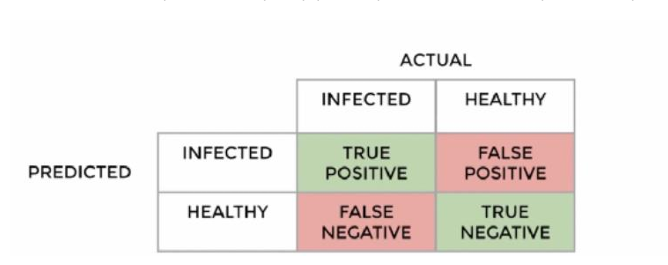
                    
-  **true positive** - да / да    - мы хотели бы  это максимизировать
-  **true-negative** - нет / нет  - мы хотели бы  это максимизировать

-  **false-positive**, ложно-положительный результат. Модель по ошибке выдает положительный результат
-  **false negative**. Ложно-отрицательный результат

1. **accuracy** -  Как часто модель дает правильное предсказание?   

$\frac{(TP+TN)}{total}$

- Это общая оценка, но она не чувствительна к дисбалансу классов.

2. **recall** - Из всех положительных случаев, какой процент этих случаев был обнаружен?  

$\frac{TP}{TotalActualPositives(TP+FN)}$

- Эта метрика особенно полезна для тех моделей, которые оказались переобучены, overfit.
- Recall = полнота охвата

3. **precision** - Когда наш тест предсказывает положительный результат, то как часто это предсказание правильное?  

$\frac{TP}{TotalPredictedPositives(TP+FP)}$ 

- Precision = качество твоих "да"


4. **ROC-AUC** 
- false negatives во многих задачах намного опаснее, чем false positives
-  если мы возьмем различные уровни линии для разделения двух классов (0.5, 0.4 и так далее). В каждом случае мы можем посчитать соотношение true positive и true negative. 
- Если мы нанесем эти точки на график, то как раз и построим ROC-кривую.

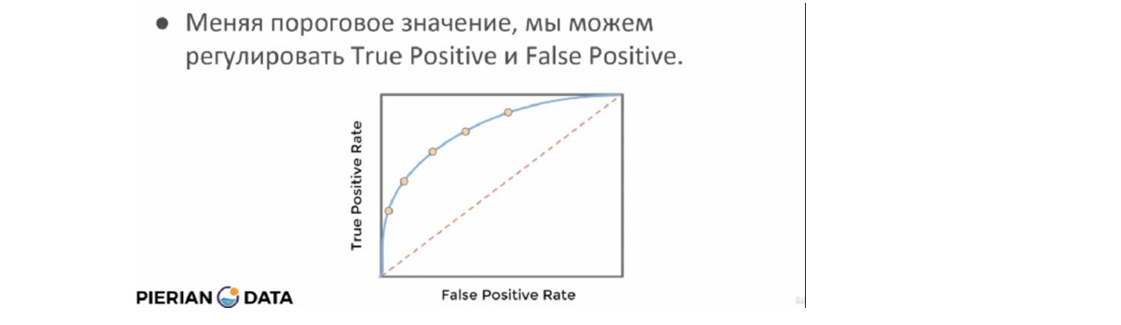

-  Если же мы хотим сравнить два графика ROC между собой, то для каждого графика можно вычислить площадь под графиком (AUC)

Площадь под ROC-кривой, которая показывает баланс между:
- True Positive Rate (чувствительность/полнота, т.е. recall)

$\frac{TP}{TP+FN}$

- False Positive Rate (ошибочные срабатывания) -насколько часто модель ошибочно срабатывает на "не тех"

$\frac{FP}{FP+TN)}$


In [28]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')  
rec = recall_score(y_test, y_pred, average='weighted') # average='weighted' берёт среднее с учётом размера каждого класса

1. Accuracy учитывает все классы пропорционально их размеру (доля правильных предсказаний во всём наборе данных)
2. precision и recall считаются по классам отдельно, а потом усредняются. 
- macro — среднее по всем классам;
- weighted — среднее с учётом доли каждого класса;
- micro — общий подсчёт TP/FP/FN по всем классам.

In [29]:
y_test_bin = label_binarize(y_test, classes=svm.classes_)   # превращает в двоичную классификацию для ROC
roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr') 
# multi_class='ovr' — one-vs-rest (один против остальных) -> считает ROC AUC для пары -> усредняет (с учетом размера класса average='weighted')

print(f"accuracy is {acc:.5f}")
print(f"precision is {prec:.5f}")
print(f"recall is {rec:.5f}")
print(f"roc_auc is {roc_auc:.5f}")

accuracy is 0.88757
precision is 0.89267
recall is 0.88757
roc_auc is 0.98168


## 3. Decision tree

1. The same task for decision tree

In [30]:
dt = DecisionTreeClassifier(max_depth=25, class_weight='balanced', criterion='entropy', random_state=21)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)

In [31]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

In [32]:
y_test_bin = label_binarize(y_test, classes=dt.classes_)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

print(f"accuracy is {acc:.5f}")
print(f"precision is {prec:.5f}")
print(f"recall is {rec:.5f}")
print(f"roc_auc is {roc_auc:.5f}")

accuracy is 0.90533
precision is 0.90667
recall is 0.90533
roc_auc is 0.94458


## 4. Random forest

1. The same task for random forest.

In [33]:
rf = RandomForestClassifier(n_estimators=100, max_depth=26,class_weight='balanced', criterion='entropy', random_state=21)

rf.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)

In [34]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=dt.classes_)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

print(f"accuracy is {acc:.5f}")
print(f"precision is {prec:.5f}")
print(f"recall is {rec:.5f}")
print(f"roc_auc is {roc_auc:.5f}")

accuracy is 0.90533
precision is 0.90667
recall is 0.90533
roc_auc is 0.94458


## 5. Predictions

1. Choose the best model.
2. Analyze: for which `weekday` your model makes the most errors (in % of the total number of samples of that class in your full dataset), for which `labname` and for which `users`.
3. Save the model.

In [35]:
best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=26,
    class_weight='balanced',
    criterion='entropy',
    random_state=21
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [36]:
df_mod = X_test.copy()
df_mod['true'] = y_test
df_mod['pred'] = y_pred

In [37]:
df_mod['error'] = df_mod['true'] != df_mod['pred']

In [38]:
lab_cols = [c for c in X.columns if c.startswith('labname_')]
user_cols = [c for c in X.columns if c.startswith('uid_user_')]

In [39]:
df_mod['labname'] = df_mod[lab_cols].idxmax(axis=1).str.replace('labname_', '')
df_mod['user'] = df_mod[user_cols].idxmax(axis=1).str.replace('uid_user_', '')

In [40]:
weekday_errors = (df_mod.groupby('true')['error'].mean() * 100).sort_values(ascending=False)
weekday_errors

true
0    22.222222
4    14.285714
5     9.259259
2     6.666667
1     5.454545
6     2.816901
3     2.500000
Name: error, dtype: float64

In [41]:
lab_errors = (
    df_mod.groupby('labname')['error']
    .mean()
    .sort_values(ascending=False) * 100
)

lab_errors

labname
lab03       100.000000
laba04       17.142857
lab05s       16.666667
laba06       11.111111
laba04s       8.000000
code_rvw      7.692308
laba06s       6.666667
project1      4.838710
laba05        2.127660
lab03s        0.000000
Name: error, dtype: float64

In [42]:
user_errors = (
    df_mod.groupby('user')['error']
    .mean()
    .sort_values(ascending=False) * 100
)

user_errors

user
6     50.000000
16    20.000000
18    16.666667
27    16.666667
3     14.285714
30    12.500000
31    11.111111
2     10.714286
19    10.526316
24     9.090909
25     9.090909
29     9.090909
10     8.333333
4      7.407407
14     3.225806
1      0.000000
15     0.000000
13     0.000000
12     0.000000
17     0.000000
26     0.000000
22     0.000000
23     0.000000
20     0.000000
21     0.000000
28     0.000000
8      0.000000
Name: error, dtype: float64

In [43]:
joblib.dump(rf, '../data/best_rf_model.pkl')

['../data/best_rf_model.pkl']

## 6. Function

1. Write a function that takes a list of different models and a corresponding list of parameters (dicts) and returns a dict that contains all the 4 metrics for each model.

In [44]:
def evaluate_models(models, params_list, X_train, X_test, y_train, y_test):   
    """
    Принимает список моделей и список словарей параметров.
    Возвращает словарь с метриками accuracy, precision, recall, roc-auc для каждой модели.
    """
    results = {}

    for model, params in zip(models, params_list):
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')

        auc = roc_auc_score(y_test, y_proba, average='weighted', multi_class='ovr')
        
        results[type(model).__name__] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "roc_auc": auc
        }

    return results

In [45]:
models = [
    RandomForestClassifier(random_state=21),
    SVC(probability=True, random_state=21)
]

params_list = [
    {"n_estimators": 100, "max_depth": 10},
    {"kernel": "linear", "C": 1.0}
]

results = evaluate_models(models, params_list, X_train, X_test, y_train, y_test)
pd.DataFrame(results).T

,accuracy,precision,recall,roc_auc
RandomForestClassifier,0.843195,0.861193,0.843195,0.975091
SVC,0.718935,0.727137,0.718935,0.921152
